<a href="https://colab.research.google.com/github/tuli-pen/maths_machine_learning/blob/master/Hoeffding_inequaility_doesnt_apply.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 1.10 — Hoeffding inequaility doesn't apply

Este cuaderno ilustra **por qué la desigualdad de Hoeffding no aplica a la moneda seleccionada mediante una regla adaptativa** (como elegir la que tiene el número mínimo de caras), aunque sí aplica a una única moneda pre-especificada.

**Configuración:**
- Lanzar **1,000 monedas justas**, cada una **10 veces**.
- Enfocarse en tres monedas:
  - $c_1$: la **primera** moneda lanzada.
  - $c_{rand}$: una moneda elegida **al azar**.
  - $c_{min}$: la moneda con la **frecuencia mínima de caras** (empates resueltos por el índice más bajo).
- $\nu_1$, $\nu_{rand}$, $\nu_{min}$: fracción de caras para las respectivas monedas.
- $\mu = 0.5$ verdadero para todas las monedas (justas).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec




N_MONEDAS       = 1_000
N_LANZAMIENTOS  = 10
N_EJECUCIONES   = 100_000
MU              = 0.5

print(f"Ejecutando {N_EJECUCIONES:,} experimentos — {N_MONEDAS:,} monedas × {N_LANZAMIENTOS} lanzamientos cada una")

Ejecutando 100,000 experimentos — 1,000 monedas × 10 lanzamientos cada una


## (a) Determinando el valor de μ para cada moneda

Dado que las 1,000 monedas son **justas** desde su fabricación, se cumple que:

$$\mu_1 = \mu_{rand} = \mu_{min} = 0.5$$

El punto central a entender aquí es que **μ no cambia por moneda** — lo que sí cambia es la *distribución de ν* una vez que aplicamos una regla de selección sobre los resultados observados.

## (b) Simulación del experimento: obteniendo ν₁, ν_azar y ν_min

In [ ]:
# Simular en lotes para mantener bajo el uso de memoria (~50 MB en vez de 7 GB)
LOTE = 1000  # ejecuciones por lote

nu_1    = np.empty(N_EJECUCIONES)
nu_azar = np.empty(N_EJECUCIONES)
nu_min  = np.empty(N_EJECUCIONES)

for inicio in range(0, N_EJECUCIONES, LOTE):
    fin = min(inicio + LOTE, N_EJECUCIONES)
    tam_lote = fin - inicio
    # Forma: (tam_lote, N_MONEDAS, N_LANZAMIENTOS) — int8 ahorra 8x memoria vs int64
    lanzamientos = np.random.randint(0, 2, size=(tam_lote, N_MONEDAS, N_LANZAMIENTOS), dtype=np.int8)
    frec  = lanzamientos.mean(axis=2)  # forma: (tam_lote, N_MONEDAS)

    nu_1[inicio:fin]    = frec[:, 0]
    idx_azar            = np.random.randint(0, N_MONEDAS, size=tam_lote)
    nu_azar[inicio:fin] = frec[np.arange(tam_lote), idx_azar]
    idx_min              = np.argmin(frec, axis=1)
    nu_min[inicio:fin]  = frec[np.arange(tam_lote), idx_min]

print(f'ν₁     — media={nu_1.mean():.4f}, std={nu_1.std():.4f}')
print(f'ν_azar — media={nu_azar.mean():.4f}, std={nu_azar.std():.4f}')
print(f'ν_min  — media={nu_min.mean():.4f}, std={nu_min.std():.4f}')

ν₁     — media=0.4998, std=0.1581
ν_azar — media=0.4997, std=0.1582
ν_min  — media=0.0377, std=0.0485


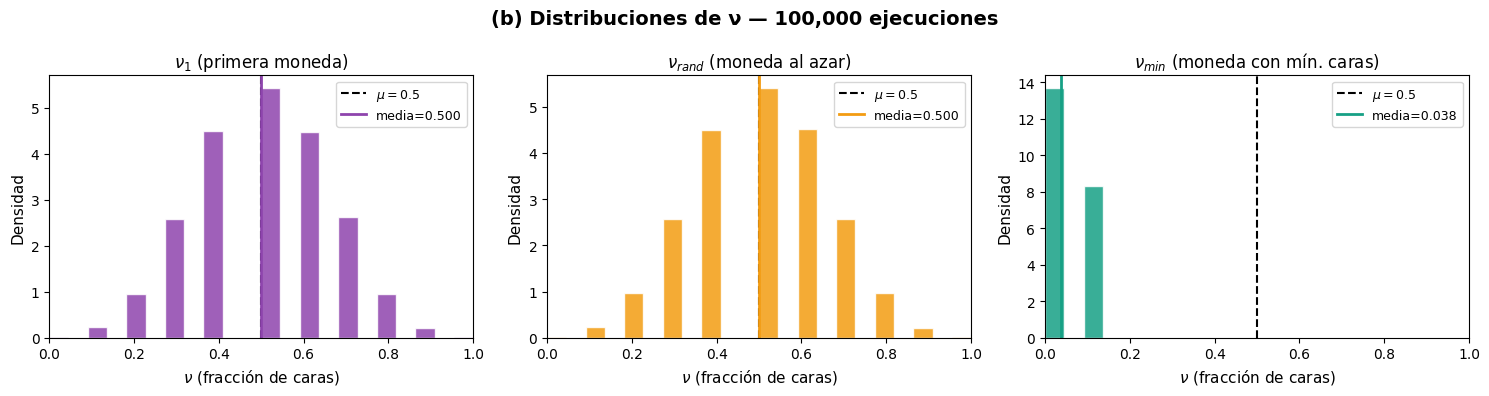

In [ ]:
# ── Graficar histogramas ────────────────────────────────────────────────────
bordes = np.linspace(0, 1, 23)  # 0, 0.1, 0.2, ... 1.0 (pasos de 1/N_LANZAMIENTOS)

figura, ejes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
figura.suptitle("(b) Distribuciones de ν — 100,000 ejecuciones", fontsize=14, fontweight='bold')

datos    = [nu_1,    nu_azar,  nu_min]
etiquetas = [r'$\nu_1$ (primera moneda)', r'$\nu_{rand}$ (moneda al azar)', r'$\nu_{min}$ (moneda con mín. caras)']
colores = ['#8E44AD', '#F39C12', '#16A085']  # morado, naranja, verde azulado

for eje, nu, etiqueta, color in zip(ejes, datos, etiquetas, colores):
    eje.hist(nu, bins=bordes, color=color, edgecolor='white', alpha=0.85, density=True)
    eje.axvline(MU, color='black', linestyle='--', linewidth=1.5, label=r'$\mu=0.5$')
    eje.axvline(nu.mean(), color=color, linestyle='-', linewidth=2,
               label=f'media={nu.mean():.3f}')
    eje.set_title(etiqueta, fontsize=12)
    eje.set_xlabel(r'$\nu$ (fracción de caras)', fontsize=11)
    eje.set_ylabel('Densidad', fontsize=11)
    eje.legend(fontsize=9)
    eje.set_xlim(0, 1)

plt.tight_layout()
plt.show()

**Observaciones:**
- $\nu_1$ y $\nu_{rand}$ son aproximadamente **simétricas alrededor de 0.5** — consistente con una moneda justa.
- $\nu_{min}$ está **fuertemente sesgada hacia la izquierda** — casi siempre toma valores pequeños (cerca de 0), aunque $\mu_{min} = 0.5$.

## (c) Comparando la probabilidad empírica P[|ν − μ| > ε] contra la cota de Hoeffding

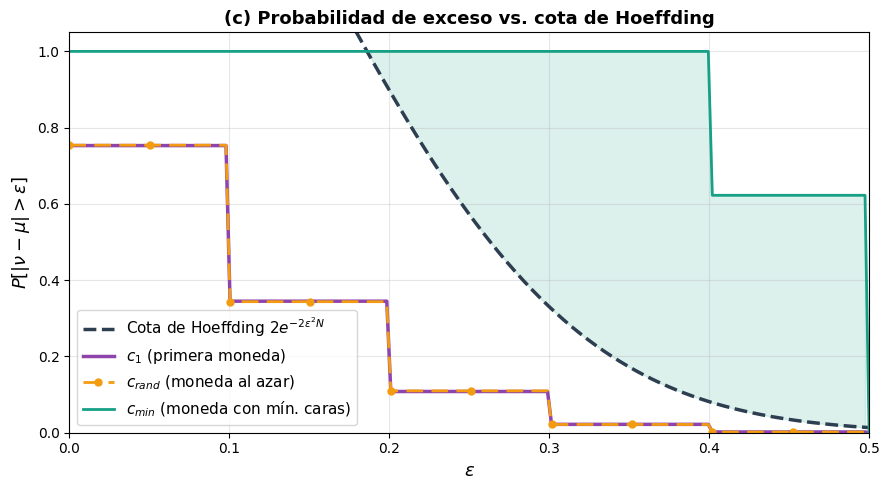

In [ ]:
epsilons = np.linspace(0, 0.5, 200)

def prob_exceso(nu, mu, valores_eps):
    """P[|ν - μ| > ε] empírica para cada ε."""
    return np.array([(np.abs(nu - mu) > e).mean() for e in valores_eps])

# Cota de Hoeffding: 2 * exp(-2 * ε² * N)
hoeffding = 2 * np.exp(-2 * epsilons**2 * N_LANZAMIENTOS)

p_1    = prob_exceso(nu_1,    MU, epsilons)
p_azar = prob_exceso(nu_azar, MU, epsilons)
p_min  = prob_exceso(nu_min,  MU, epsilons)

figura, eje = plt.subplots(figsize=(9, 5))

eje.plot(epsilons, hoeffding, color='#2C3E50', linestyle='--', linewidth=2.5, label='Cota de Hoeffding $2e^{-2\\varepsilon^2 N}$')
eje.plot(epsilons, p_1,    color='#8E44AD', linewidth=2.5,
        linestyle='-',  label=r'$c_1$ (primera moneda)')
eje.plot(epsilons, p_azar, color='#F39C12',  linewidth=2,
        linestyle='--', dashes=(6,3), marker='o', markevery=20,
        markersize=5,   label=r'$c_{rand}$ (moneda al azar)')
eje.plot(epsilons, p_min,  color='#16A085',    linewidth=2, label=r'$c_{min}$ (moneda con mín. caras)')

eje.set_xlabel(r'$\varepsilon$', fontsize=13)
eje.set_ylabel(r'$P[|\nu - \mu| > \varepsilon]$', fontsize=13)
eje.set_title('(c) Probabilidad de exceso vs. cota de Hoeffding', fontsize=13, fontweight='bold')
eje.legend(fontsize=11)
eje.set_xlim(0, 0.5)
eje.set_ylim(0, 1.05)
eje.grid(True, alpha=0.3)


eje.fill_between(epsilons, hoeffding, p_min,
                where=(p_min > hoeffding),
                color='#16A085', alpha=0.15, label='Hoeffding violada')

plt.tight_layout()

plt.show()

## (d) ¿Cuáles de las tres monedas respetan la cota de Hoeffding?



<table style="width:100%; border-collapse: collapse; font-size: 15px;">
  <thead>
    <tr style="background-color:#2C3E50; color:white;">
      <th style="padding:10px; text-align:center; border:1px solid #ddd;">Moneda</th>
      <th style="padding:10px; text-align:center; border:1px solid #ddd;">¿Cumple Hoeffding?</th>
      <th style="padding:10px; text-align:left; border:1px solid #ddd;">Razón</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color:#EAFAF1;">
      <td style="padding:10px; text-align:center; border:1px solid #ddd;"><b>$c_1$</b> (primera)</td>
      <td style="padding:10px; text-align:center; border:1px solid #ddd; color:#16A085; font-weight:bold;">✅ Sí cumple</td>
      <td style="padding:10px; border:1px solid #ddd;">Se fija <i>antes</i> de observar cualquier dato. Hoeffding aplica a cualquier urna pre-especificada.</td>
    </tr>
    <tr style="background-color:#EAFAF1;">
      <td style="padding:10px; text-align:center; border:1px solid #ddd;"><b>$c_{rand}$</b> (al azar)</td>
      <td style="padding:10px; text-align:center; border:1px solid #ddd; color:#16A085; font-weight:bold;">✅ Sí cumple</td>
      <td style="padding:10px; border:1px solid #ddd;">Se elige independientemente de los resultados. Estadísticamente equivalente a $c_1$.</td>
    </tr>
    <tr style="background-color:#FDEDEC;">
      <td style="padding:10px; text-align:center; border:1px solid #ddd;"><b>$c_{min}$</b> (mín. caras)</td>
      <td style="padding:10px; text-align:center; border:1px solid #ddd; color:#C0392B; font-weight:bold;">❌ No cumple</td>
      <td style="padding:10px; border:1px solid #ddd;">Se elige <i>adaptativamente</i> — por construcción es la moneda más sesgada hacia sello. Esto introduce un sesgo de selección sistemático.</td>
    </tr>
  </tbody>
</table>

**¿Por qué $c_{min}$ termina violando Hoeffding?**  
La desigualdad de Hoeffding parte del supuesto de que la hipótesis (moneda) se fija **independientemente de la muestra**. Al elegir $c_{min}$ *después* de observar todos los resultados, en realidad estamos recorriendo 1,000 monedas y quedándonos con la más extrema. La probabilidad de que *al menos una* de esas 1,000 monedas muestre una desviación grande respecto a 0.5 es mucho mayor que la de cualquier moneda individual fijada de antemano — esto es precisamente el problema de **pruebas múltiples / urnas múltiples**.

Dicho de forma más precisa: sea $M=1000$ el número de monedas. La probabilidad de que el *mínimo* se desvíe más de $\varepsilon$ satisface:
$$P\left[\nu_{min} \leq \mu - \varepsilon\right] \;\leq\; M \cdot e^{-2\varepsilon^2 N}$$
cota que puede ser mucho mayor que $2e^{-2\varepsilon^2 N}$ cuando ε es pequeño.

## (e) ¿Cómo se relaciona esto con el problema de Múltiples Urnas?

Este experimento funciona como una ilustración concreta del problema de **múltiples urnas** (o múltiples hipótesis) que aparece en la teoría del aprendizaje.

### Urna única (una hipótesis)
Si fijamos **una hipótesis** $h$ *antes* de observar los datos y calculamos su error de entrenamiento $E_{in}(h)$, la desigualdad de Hoeffding garantiza:
$$P\left[|E_{in}(h) - E_{out}(h)| > \varepsilon\right] \leq 2e^{-2\varepsilon^2 N}$$
Esto es exactamente lo que demuestran $c_1$ y $c_{rand}$ — la cota se cumple.

### Múltiples urnas ($M$ hipótesis)
En la práctica, un algoritmo de aprendizaje explora un **conjunto de hipótesis** $\mathcal{H} = \{h_1, \ldots, h_M\}$ y retorna la hipótesis $g$ con **error de entrenamiento mínimo** — análogo a elegir $c_{min}$.

Una cota de unión (union bound) da:
$$P\left[\exists h_m: |E_{in}(h_m) - E_{out}(h_m)| > \varepsilon\right] \leq \sum_{m=1}^{M} P\left[|E_{in}(h_m) - E_{out}(h_m)| > \varepsilon\right] \leq 2Me^{-2\varepsilon^2 N}$$

La cota tipo Hoeffding correcta para $g$ (elegida adaptativamente) es entonces:
$$P\left[|E_{in}(g) - E_{out}(g)| > \varepsilon\right] \leq 2Me^{-2\varepsilon^2 N}$$




La cota ingenua de Hoeffding solo es válida cuando la hipótesis se elige *independientemente* de los datos. Cuando la hipótesis se selecciona minimizando el error de entrenamiento sobre muchos candidatos, el error de entrenamiento es una **estimación optimista (sesgada)** del error verdadero — la brecha es mayor, y se necesita un factor de corrección de $M$ (o eventualmente la dimensión VC).

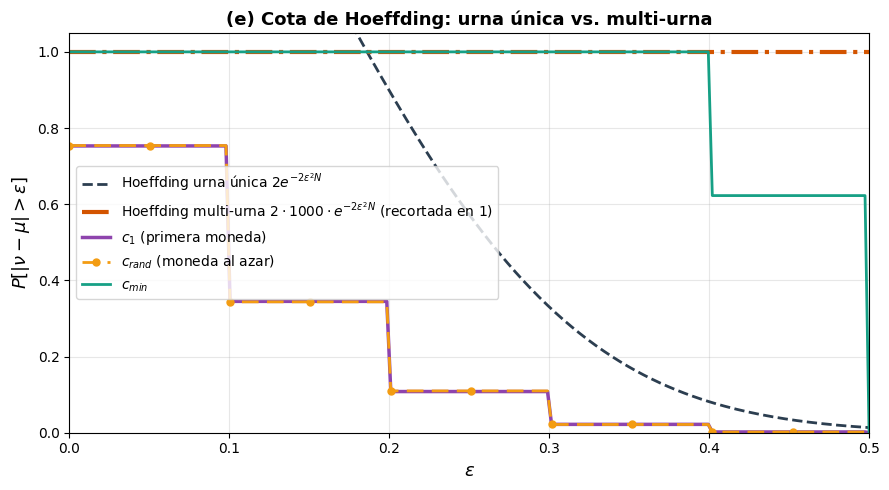

In [ ]:

M = N_MONEDAS
hoeffding_multi = np.minimum(1.0, 2 * M * np.exp(-2 * epsilons**2 * N_LANZAMIENTOS))

figura, eje = plt.subplots(figsize=(9, 5))

eje.plot(epsilons, hoeffding,      color='#2C3E50', linestyle='--', linewidth=2.0, label='Hoeffding urna única $2e^{-2\\varepsilon^2 N}$')
eje.plot(epsilons, hoeffding_multi,   color='#D35400', linestyle='-.', linewidth=3.0, label=f'Hoeffding multi-urna $2\\cdot {M}\\cdot e^{{-2\\varepsilon^2 N}}$ (recortada en 1)')
eje.plot(epsilons, p_1,    color='#8E44AD', linewidth=2.5,
        linestyle='-',  label=r'$c_1$ (primera moneda)')
eje.plot(epsilons, p_azar, color='#F39C12',  linewidth=2,
        linestyle='--', dashes=(6,3), marker='o', markevery=20,
        markersize=5,   label=r'$c_{rand}$ (moneda al azar)')
eje.plot(epsilons, p_min,  color='#16A085',    linewidth=2, label=r'$c_{min}$')

eje.set_xlabel(r'$\varepsilon$', fontsize=13)
eje.set_ylabel(r'$P[|\nu - \mu| > \varepsilon]$', fontsize=13)
eje.set_title('(e) Cota de Hoeffding: urna única vs. multi-urna', fontsize=13, fontweight='bold')
eje.legend(fontsize=10)
eje.set_xlim(0, 0.5)
eje.set_ylim(0, 1.05)
eje.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

**La cota multi-urna (línea punteada-guion) acota correctamente por arriba a $c_{min}$**, confirmando que seleccionar la moneda con peor desempeño es equivalente a un algoritmo de aprendizaje que busca entre $M$ hipótesis.